# 06 — Pure Pursuit Path Tracking

**Section:** Path Tracking · **Mirrors MATLAB:** *Path Following with Obstacle Avoidance*

Pure pursuit is a geometric controller that finds a point on the reference path at a fixed **look-ahead distance** ahead of the robot, then computes the curvature that would carry the robot to that point in a single arc.

For a unicycle with linear velocity `v`, the commanded angular velocity is `ω = 2v sin(α) / L_d` where `α` is the angle from the robot heading to the look-ahead point.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sinusoidal reference path
xs_ref = np.linspace(0, 30, 400)
ys_ref = 3 * np.sin(xs_ref * 0.3)
path = np.column_stack([xs_ref, ys_ref])

x = np.array([0.0, -2.0, 0.0])      # x, y, theta
v = 1.5
Ld = 1.8
dt = 0.05
T = 25.0
N = int(T / dt)

hist = np.zeros((N, 3))
lookaheads = np.zeros((N, 2))


In [2]:
for i in range(N):
    d = np.linalg.norm(path - x[:2], axis=1)
    j = int(np.argmin(d))
    while j < len(path) - 1 and np.linalg.norm(path[j] - x[:2]) < Ld:
        j += 1
    target = path[j]
    alpha = np.arctan2(target[1] - x[1], target[0] - x[0]) - x[2]
    omega = 2 * v * np.sin(alpha) / Ld

    x = x + dt * np.array([v * np.cos(x[2]), v * np.sin(x[2]), omega])
    hist[i] = x
    lookaheads[i] = target


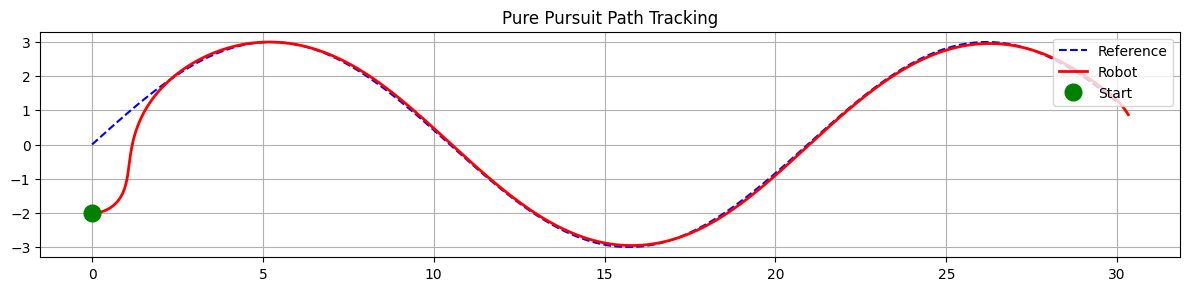

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs_ref, ys_ref, 'b--', lw=1.5, label='Reference')
ax.plot(hist[:, 0], hist[:, 1], 'r-', lw=2, label='Robot')
ax.plot(0, -2, 'go', markersize=12, label='Start')
ax.legend(loc='upper right'); ax.grid(); ax.set_aspect('equal')
ax.set_title('Pure Pursuit Path Tracking')
plt.tight_layout()
plt.show()
